In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
140,2025-26,1630598,Aaron Wiggins,Aaron,1610612760,OKC,Oklahoma City Thunder,22501155,2026-04-07T00:00:00,OKC @ LAL,W,19.950000,4,7,0.571,2,4,0.500,0,0,0.0,0,2,2,0,1,1,0,0,2,0,10,4,14.4,0,0,16.0,1,19:57,1,109.7,111.6,111.6,103.3,102.3,102.3,6.4,9.3,9.3,0.000,0.00,0.0,0.000,0.091,0.044,12.5,12.5,0.714,0.714,0.163,0.168,103.89,103.46,86.22,103.46,0.077,43,4.0,7.0,45,89,0.506,21,41,0.512,12,14,0.857,10,36,46,29,12.0,15,2,3,21,12,123,36.0,126.6,128.1,91.0,89.7,35.6,38.4,0.644,2.42,21.2,0.273,0.776,0.538,0.125,0.624,0.646,96.4,96.5,80.42,96,0.655,1610612747,LAL,Los Angeles Lakers,32,73,0.438,9,26,0.346,14,31,0.452,8,30,38,26,17.0,7,3,2,12,21,87,-36.0,91.0,89.7,126.6,128.1,-35.6,-38.4,0.813,1.53,19.4,0.224,0.727,0.462,0.175,0.500,0.502,96.4,96.5,80.42,97,0.345,NaN,SG,27.0,0
139,2025-26,1642347,Jamal Shead,Jamal,1610612761,TOR,Toronto Raptors,22501151,2026-04-07T00:00:00,TOR vs. MIA,W,23.560000,1,4,0.250,1,3,0.333,0,0,0.0,0,1,1,11,3,0,0,0,2,1,3,27,17.7,0,0,16.0,1,23:34,1,129.4,128.0,128.0,71.6,71.2,71.2,57.8,56.8,56.8,0.423,3.67,61.1,0.000,0.031,0.018,16.7,16.7,0.375,0.375,0.119,0.122,102.97,103.90,86.59,103.90,0.071,50,1.0,4.0,49,99,0.495,12,28,0.429,11,16,0.688,15,41,56,34,12.0,9,5,3,19,15,121,26.0,117.4,118.6,91.0,93.1,26.4,25.5,0.694,2.83,22.2,0.315,0.759,0.545,0.118,0.556,0.571,103.7,102.0,85.00,102,0.634,1610612748,MIA,Miami Heat,33,91,0.363,12,44,0.273,17,19,0.895,10,34,44,26,15.0,3,3,5,15,19,95,-26.0,91.0,93.1,117.4,118.6,-26.4,-25.5,0.788,1.73,18.3,0.241,0.685,0.455,0.147,0.429,0.478,103.7,102.0,85.00,102,0.366,NaN,PG,23.0,0
138,2025-26,203914,Gary Harris,Gary,1610612749,MIL,Milwaukee Bucks,22501150,2026-04-07T00:00:00,MIL @ BKN,L,21.101667,3,9,0.333,1,4,0.250,0,0,0.0,1,2,3,1,0,0,2,1,1,1,7,-11,18.1,0,0,16.0,1,21:06,1,80.0,77.8,77.8,105.7,104.5,104.5,-25.7,-26.8,-26.8,0.100,0.00,10.0,0.043,0.105,0.071,0.0,0.0,0.389,0.389,0.170,0.185,99.27,101.22,84.35,101.22,0.069,45,3.0,9.0,35,81,0.432,15,45,0.333,5,8,0.625,9,35,44,25,20.0,6,7,4,20,13,90,-6.0,94.2,96.8,99.9,103.2,-5.7,-6.5,0.714,1.25,18.8,0.313,0.814,0.549,0.215,0.525,0.532,95.8,93.0,77.50,93,0.464,1610612751,BKN,Brooklyn Nets,33,75,0.440,9,26,0.346,21,23,0.913,3,29,32,18,14.0,11,4,7,13,20,96,6.0,99.9,103.2,94.2,96.8,5.7,6.5,0.545,1.29,15.1,0.186,0.688,0.451,0.151,0.500,0.564,95.8,93.0,77.50,93,0.536,NaN,SG,31.0,0
149,2025-26,1642967,John Poulakidas,John,1610612742,DAL,Dallas Mavericks,22501

In [3]:
def apply_bayesian_ppm(df, confidence_k=20, min_minutes=1.0):
    """
    Shrink player PTS/MIN toward a (pos, STARTING) role prior.
    confidence_k: pseudo sample size for the prior (same interpretation as minutes).
    min_minutes: only rows with MIN >= this contribute to PPM (avoids divide-by-zero).
    """
    df = df.copy()
    df["_ppm"] = np.where(df["MIN"] >= min_minutes, df["PTS"] / df["MIN"], np.nan)

    priors = df.groupby(["pos", "STARTING"], dropna=False)["_ppm"].mean().to_dict()

    player_stats = df.groupby("PLAYER_ID", as_index=False).agg(
        player_mean_ppm=("_ppm", "mean"),
        games_played=("_ppm", "count"),
    )

    df = df.merge(player_stats, on="PLAYER_ID", how="left")

    def _prior_for_row(row):
        key = (row["pos"], row["STARTING"])
        v = priors.get(key)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return float(df["_ppm"].mean())
        return float(v)

    df["prior_ppm"] = df.apply(_prior_for_row, axis=1)

    df["bayesian_ppm_proj"] = (
        (df["games_played"] * df["player_mean_ppm"]) + (confidence_k * df["prior_ppm"])
    ) / (df["games_played"] + confidence_k)

    df["bayesian_ppm_proj"] = df["bayesian_ppm_proj"].round(4)
    df = df.drop(columns=["_ppm"], errors="ignore")

    return df["bayesian_ppm_proj"]

In [4]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['PTS_PER_POSS'] = df['PTS'] / df['POSS'].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    # df['STARTING'] = df['START_POSITION'].notna().astype(int)
    df['BAYES_PPM_PROJ'] = apply_bayesian_ppm(df)
    df = ppm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TRUE_USG_L10'] = df['POSS_roll10'] / df['TEAM_POSS_roll10']

    df["PTS_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["PTS_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    df["PTS_PER_MIN_3_ewm"] = df.groupby("PLAYER_ID")["PTS_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=3).mean())
    df['PPM_MOMENTUM'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_10_ewm']

    df['POSS_DIFF_L10'] = df['POSS_roll10'] - df['TEAM_POSS_roll10']
    df['TS_PCT_DELTA'] = df['TS_PCT_roll10'] - df['TEAM_TS_PCT_roll10']

    df["FGA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FGA_PER_MIN_5_ewm"] = df.groupby("PLAYER_ID")["FGA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=5).mean())
    
    df["3PA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["3PA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["FTA_PER_MIN_10_ewm"] = df.groupby("PLAYER_ID")["FTA_PER_MIN"].transform(lambda x: x.shift(1).ewm(span=10).mean())
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])

    player_avgs = df[df['MIN'] > 0].groupby('PLAYER_ID')['MIN'].apply(
    lambda x: (x >= 12).mean())
    eligible = player_avgs[player_avgs >= 0.60].index
    df = df[df['PLAYER_ID'].isin(eligible)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
# df.to_csv('data/processed/training/S26_TRAINING_PPM.csv', index=False)
df.tail()

(83728, 269)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,PTS_PER_POSS,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,BAYES_PPM_PROJ,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,PTS_PER_POSS_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,AST_roll3,TOV_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,PTS_PER_POSS_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,AST_roll5,TOV_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,PTS_PER_POSS_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,AST_roll10,TOV_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,NET_RATING_roll5,TEAM_PACE_roll10,TEAM_PTS_roll10,TEAM_POSS_roll10,TEAM_TS_PCT_roll10,MIN_share_proxy,PTS_share_proxy,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,PLAYER_IS_TEAM_STAR,STAR_SAT_OUT,TEAM_PTS_PER_MIN_RANK_L5,TEAM_PTS_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,TRUE_USG_L10,PTS_PER_MIN_10_ewm,PTS_PER_MIN_5_ewm,PTS_PER_MIN_3_ewm,PPM_MOMENTUM,POSS_DIFF_L10,TS_PCT_DELTA,FGA_PER_MIN_10_ewm,FGA_PER_MIN_5_ewm,3PA_PER_MIN_10_ewm,FTA_PER_MIN_10_ewm,GP,POSITION_ENC,START_POSITION
83723,2025-26,1643158,Andersson Garcia,Andersson,1610612762,UTA,Utah Jazz,22501004,2026-03-18,UTA @ MIN,L,24.12,1,5,0.200,0,2,0.000,2,2,1.000,5,3,8,3,0,0,2,2,2,3,4,-24,24.1,0,0,19.0,1,24:07,1,93.9,94.7,94.7,136.7,134.5,134.5,-42.8,-39.7,-39.7,0.167,0.0,33.3,0.135,0.125,0.131,0.0,0.0,0.200,0.340,0.080,0.081,113.97,114.44,95.37,114.44,0.065,57,1.0,5.0,40,93,0.430,13,39,0.333,18,26,0.692,17,29,46,26,24.0,10,5,5,23,23,111,-36.0,99.6,101.8,128.7,133.6,-29.1,-31.8,0.650,1.08,16.7,0.373,0.660,0.500,0.220,0.500,0.531,112.8,109.5,91.25,109,0.338,1610612750,MIN,Minnesota Timberwolves,52,96,0.542,18,39,0.462,25,30,0.833,12,34,46,39,17.0,15,5,5,23,23,147,36.0,128.7,133.6,99.6,101.8,29.1,31.8,0.750,2.29,23.6,0.340,0.627,0.500,0.155,0.635,0.673,

In [5]:
PPM_FEATURES = [
    # --- Tier 1: Core Scoring Baseline ---
    'BAYES_PPM_PROJ',             # Your primary anchor
    'STARTING',
    'PTS_PER_MIN_10_ewm',         # Long-term stable rate
    'PPM_MOMENTUM',               # (PTS_PER_MIN_5_ewm - PTS_PER_MIN_10_ewm)
    'PTS_PER_POSS_roll10',
    
    # --- Tier 2: Shooting Profile & Usage ---
    'USG_PCT_roll10',             # The "Volume" driver
    '3PA_PER_MIN_10_ewm',         # (3PA_PER_MIN_10_ewm) - Helps model variance
    'TEAM_USG_RANK_L10',          # Hierarchy: Is he the 1st option or 4th?
    'POSS_DIFF_L10',
    'TS_PCT_DELTA',
    'TRUE_USG_L10',

    # --- Tier 3: Efficiency & Matchup ---
    'TS_PCT_roll10',              # True Shooting % (Efficiency baseline)
    'OPP_DEF_RATING_roll10',         # Defensive matchup difficulty
    'PACE_DIFFERENTIAL',
    'DAYS_REST',                  # Legs/fatigue affecting shooting %
    'POSITION_ENC'                # Scoring style (e.g., Center vs. Guard)
]

In [6]:
ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "MIN", "GAME_DATE"]].dropna()

split_date = ppm_df["GAME_DATE"].quantile(0.75)
train_mask = ppm_df["GAME_DATE"] <= split_date
val_mask = ~train_mask

X_train_ppm = ppm_df.loc[train_mask, PPM_FEATURES]
y_train_ppm = ppm_df.loc[train_mask, "PTS_PER_MIN"]
X_val_ppm   = ppm_df.loc[val_mask, PPM_FEATURES]
y_val_ppm   = ppm_df.loc[val_mask, "PTS_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds = {}

for q in quantiles:
    q_float = float(q)
    key = f"q_{q_float:.2f}"
    print(f"Training model for Quantile: {key}...")

    xgb_q = XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q_float,
        n_estimators=800,
        max_depth=8,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.01,
        reg_lambda=0.1,
        reg_alpha=0.1,
        random_state=42,
        n_jobs=-1,
    )

    xgb_q.fit(
        X_train_ppm,
        y_train_ppm,
        eval_set=[(X_val_ppm, y_val_ppm)],
        verbose=False,
    )

    quantile_models[key] = xgb_q
    quantile_preds[key] = xgb_q.predict(X_val_ppm)

results_df = X_val_ppm.copy()
results_df["Actual"] = y_val_ppm.values
results_df["Lower_10"] = quantile_preds["q_0.10"]
results_df["Median_50"] = quantile_preds["q_0.50"]
results_df["Upper_90"] = quantile_preds["q_0.90"]
results_df["MIN"] = ppm_df.loc[val_mask, "MIN"].values

# Optional: high-minute slice for diagnostics (PPM vs actual PTS/min when MIN >= 35)
high_min_stars = results_df[results_df["MIN"] >= 35]

print("\n--- Val rows with Actual MIN >= 35 (PPM model, target = PTS_PER_MIN) ---")
print(f"Average Actual PTS/MIN: {high_min_stars['Actual'].mean():.3f}")
print(f"Avg Median Pred PTS/MIN: {high_min_stars['Median_50'].mean():.3f}")

q50_mae = mean_absolute_error(y_val_ppm, quantile_preds["q_0.50"])
q50_rmse = np.sqrt(mean_squared_error(y_val_ppm, quantile_preds["q_0.50"]))
q50_r2 = r2_score(y_val_ppm, quantile_preds["q_0.50"])

print(f"\n[Overall Median Model] MAE: {q50_mae:.3f} PTS/min")
print(f"RMSE: {q50_rmse:.3f} PTS/min")
print(f"R-squared: {q50_r2:.2f}")

Training model for Quantile: q_0.10...
Training model for Quantile: q_0.50...
Training model for Quantile: q_0.90...

--- Val rows with Actual MIN >= 35 (PPM model, target = PTS_PER_MIN) ---
Average Actual PTS/MIN: 0.587
Avg Median Pred PTS/MIN: 0.561

[Overall Median Model] MAE: 0.168 PTS/min
RMSE: 0.221 PTS/min
R-squared: 0.29


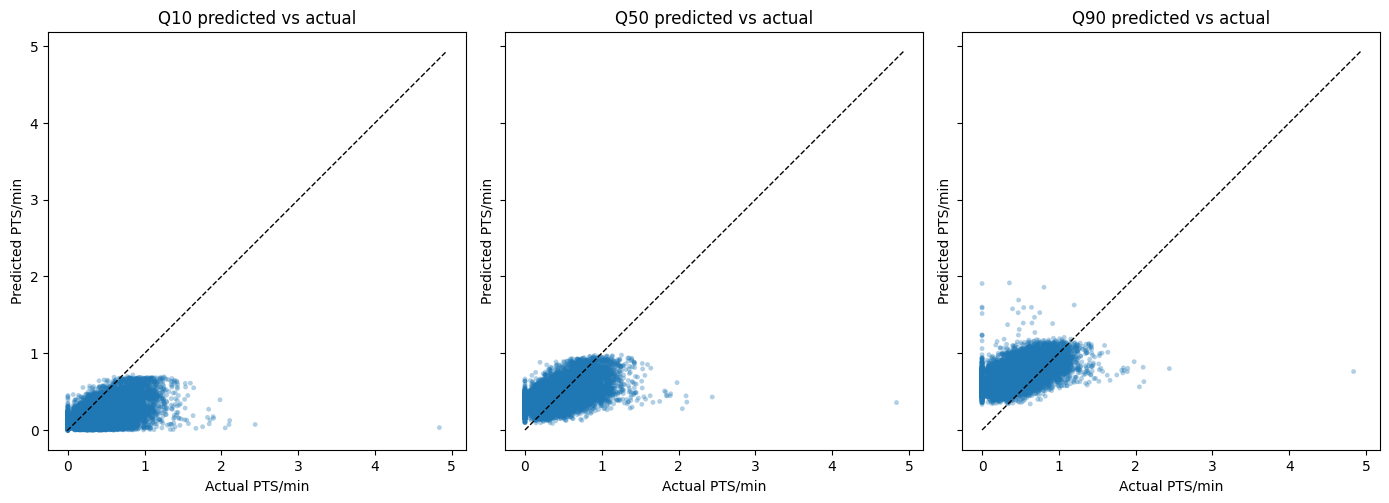

Q10 P(y ≤ pred): 0.12495630898287312
Q50 P(y ≤ pred): 0.49959221717348246
Q90 P(y ≤ pred): 0.8853547710590702
Coverage (10–90 interval): 76.04%


In [7]:
import matplotlib.pyplot as plt

y_true = y_val_ppm
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min")
    ax.set_ylabel("Predicted PTS/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%

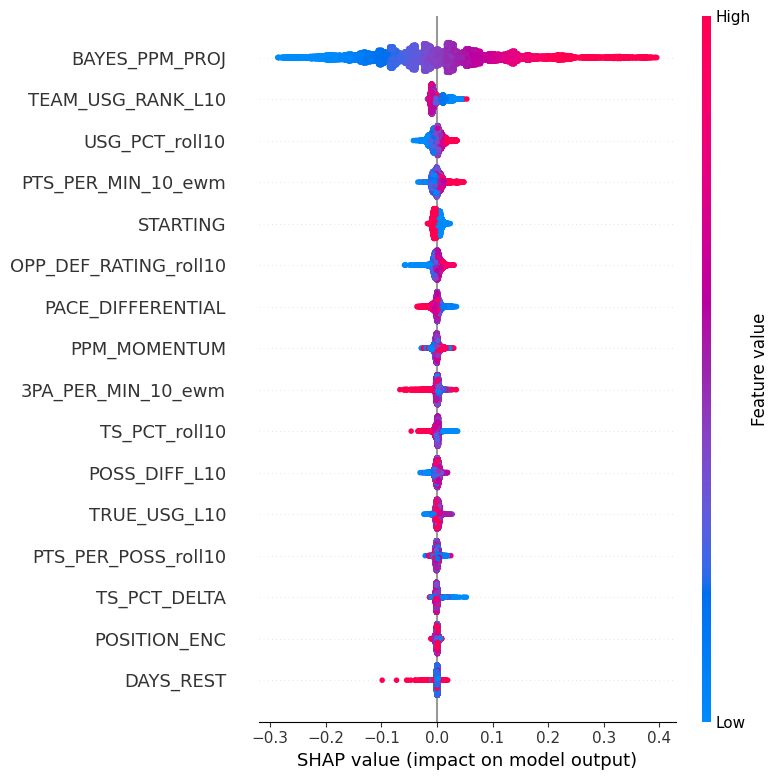

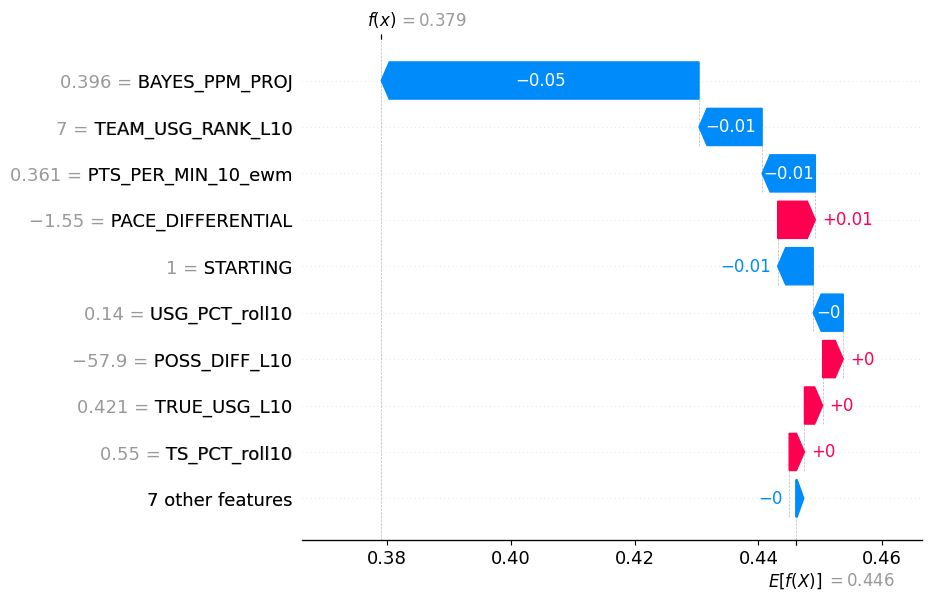

In [8]:
import shap

model = quantile_models["q_0.50"]   
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_ppm)
shap.summary_plot(shap_values, X_val_ppm, feature_names=PPM_FEATURES)
shap.plots.waterfall(shap_values[1154])

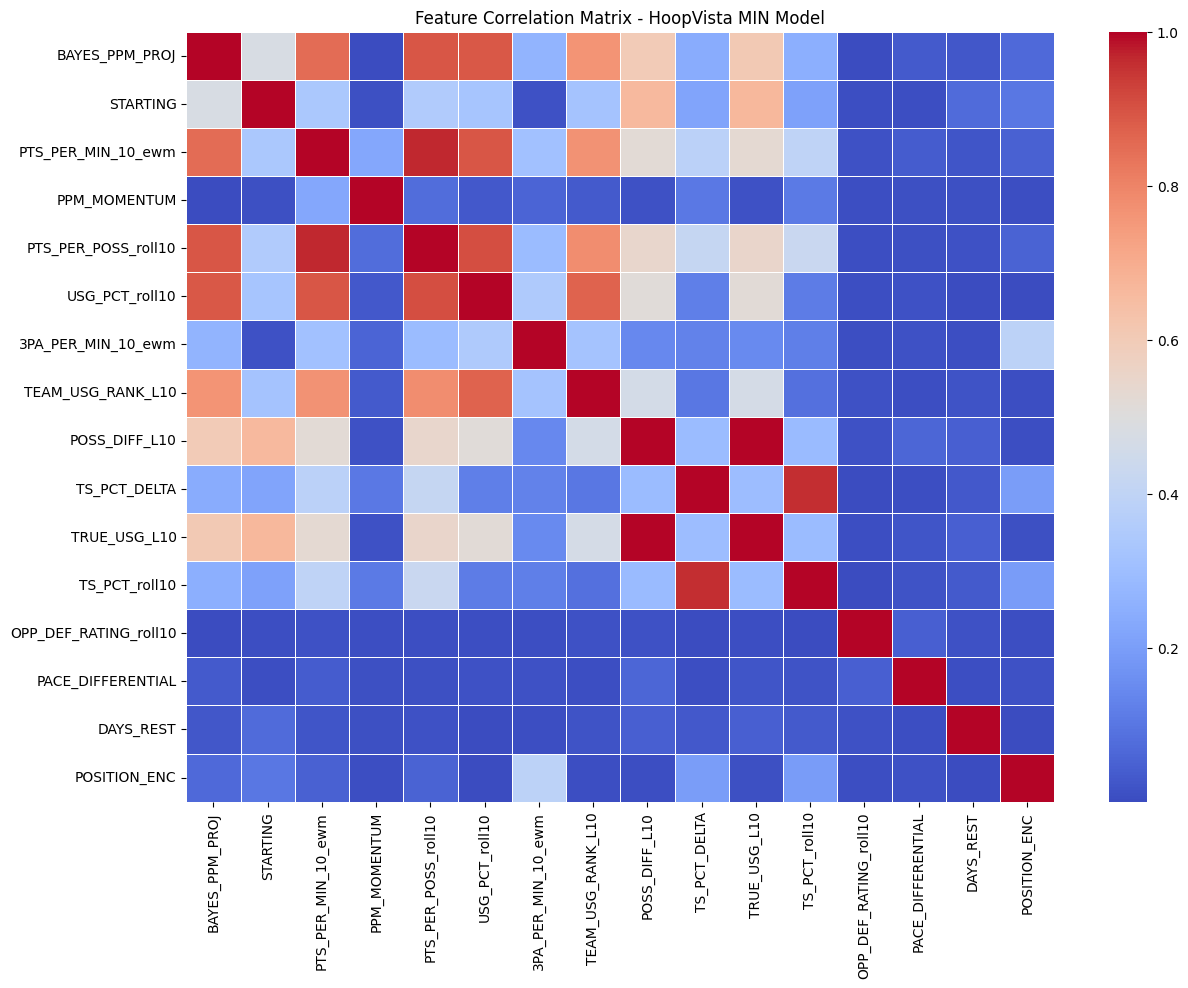

--- High Correlation Report (Threshold > 0.85) ---
TRUE_USG_L10 <-> POSS_DIFF_L10: 0.9966
PTS_PER_POSS_roll10 <-> PTS_PER_MIN_10_ewm: 0.9688
TS_PCT_roll10 <-> TS_PCT_DELTA: 0.9609
USG_PCT_roll10 <-> PTS_PER_POSS_roll10: 0.9091
USG_PCT_roll10 <-> PTS_PER_MIN_10_ewm: 0.8935
PTS_PER_POSS_roll10 <-> BAYES_PPM_PROJ: 0.8934
USG_PCT_roll10 <-> BAYES_PPM_PROJ: 0.8881
TEAM_USG_RANK_L10 <-> USG_PCT_roll10: 0.8677
PTS_PER_MIN_10_ewm <-> BAYES_PPM_PROJ: 0.8507


['PTS_PER_MIN_10_ewm',
 'PTS_PER_POSS_roll10',
 'USG_PCT_roll10',
 'TEAM_USG_RANK_L10',
 'TRUE_USG_L10',
 'TS_PCT_roll10']

In [9]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.85):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [10]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": PPM_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "src/models/saved_models/ppm_quantile_xgb.joblib")

['src/models/saved_models/ppm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [11]:
# date = pd.Timestamp.now().normalize()  # midnight today, local tz
# current_date = date.strftime("%Y-%m-%d")

# # target_date = pd.Timestamp("2026-03-26")
# # hist = df[df["GAME_DATE"] < target_date].copy()

# lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
# lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
# lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
# names = lines_dfs['NAME'].unique()
# names

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-03-26")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260408_145444.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['James Harden', 'Donovan Mitchell', 'C.J. McCollum', 'Max Strus',
       'Nickeil Alexander-Walker', 'Cade Cunningham', 'Ausar Thompson',
       'A.J. Green', 'Franz Wagner', 'Julius Randle', 'Wendell Carter Jr',
       'Anthony Black', 'Tristan da Silva', 'Jrue Holiday',
       'Scoot Henderson', 'Dylan Harper', 'Kris Murray', 'Nikola Jokic',
       'Jamal Murray', 'Aaron Gordon', 'Bruce Brown', 'Cedric Coward',
       'Cooper Flagg', 'Khris Middleton', 'Dillon Brooks',
       'Dwight Powell', 'Kawhi Leonard', 'Shai Gilgeous-Alexander',
       'Jalen Williams', 'Chet Holmgren', 'Brook Lopez', 'Derrick Jones',
       'Isaiah Hartenstein', 'Ajay Mitchell', 'Jordan Miller'],
      dtype=object)

In [12]:
import joblib

min_bundle = joblib.load("src/models/saved_models/min_quantile_xgb.joblib")
min_quantile_models = min_bundle["quantile_models"]
min_feature_names = min_bundle["feature_names"]

ppm_bundle = joblib.load("src/models/saved_models/ppm_quantile_xgb.joblib")
ppm_quantile_models = ppm_bundle["quantile_models"]
ppm_feature_names = ppm_bundle["feature_names"]

In [13]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] A.J. Green: single positional indexer is out-of-bounds
[SKIP] Wendell Carter Jr: single positional indexer is out-of-bounds
[SKIP] Derrick Jones: single positional indexer is out-of-bounds


,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,James Harden,5.714018,30.033363,39.895912,0.420654,0.586804,0.973156,2.403627,17.623699,38.824931,36.421304
1,Donovan Mitchell,11.964686,29.568192,36.937096,0.503473,0.774222,1.093084,6.023893,22.892338,40.375356,34.351463
2,CJ McCollum,14.950503,28.303493,36.752350,0.479873,0.626598,1.155750,7.174343,17.734906,42.476512,35.302169
3,Max Strus,14.461273,23.989042,30.660450,0.209653,0.376951,0.731703,3.031849,9.042702,22.434352,19.402503
4,Nickeil Alexander-Walker,15.839154,29.416533,39.264175,0.294353,0.482924,0.774588,4.662306,14.205962,30.413575,25.751269


In [15]:

# ---------------------------------------------------------
# 1. THE POINTS SIMULATION ENGINE (CONTINUOUS TRIANGULAR)
# ---------------------------------------------------------

def triangular_clip(row, q10, q50, q90, lo_scale=0.85, hi_scale=1.15, low=0.0, high=np.inf, n_sims=10_000):
    """
    Generates continuous samples for Points Per Minute or Minutes.
    Uses your specified scales (0.85/1.15) to maintain the existing distribution.
    """
    mode = float(row[q50])
    left = min(float(row[q10]) * lo_scale, mode - 0.0001)
    right = max(float(row[q90]) * hi_scale, mode + 0.0001)
    
    if not (np.isfinite(left) and np.isfinite(mode) and np.isfinite(right)):
        return np.full(n_sims, mode if np.isfinite(mode) else 0.0)
    
    samples = np.random.triangular(left, mode, right, size=n_sims)
    return np.clip(samples, low, high)

def run_pts_simulation(row, n_sims=10_000):
    """
    Paired Simulation: Minutes * PPM.
    Maintains continuous distribution for scoring.
    """
    sim_min = triangular_clip(
        row,
        "PRED_MIN_Q10", "PRED_MIN_Q50", "PRED_MIN_Q90",
        lo_scale=0.85, hi_scale=1.15, low=0, high=48, n_sims=n_sims,
    )
    
    sim_ppm = triangular_clip(
        row,
        "PRED_PPM_Q10", "PRED_PPM_Q50", "PRED_PPM_Q90",
        lo_scale=0.85, hi_scale=1.15, low=0, high=np.inf, n_sims=n_sims,
    )
    
    # Return the continuous point totals
    return sim_min * sim_ppm

# ---------------------------------------------------------
# 2. CALCULATION & FORMATTING LOOP
# ---------------------------------------------------------

def _line_lookup_from_lines_df(ldf: pd.DataFrame, name_dict: dict) -> dict:
    """
    Maps sportsbook names to canonical dataset names.
    Handles 'Jokic' vs 'Jokić' logic.
    """
    d = {}
    for _, r in ldf.iterrows():
        book_name = str(r["NAME"]).strip()
        line = r["LINE"]
        d[book_name] = line
        
        # Add the canonical version if it exists in your nameDict
        canon = name_dict.get(book_name)
        if canon:
            d[canon] = line
            
    # Reverse check: ensure variants point to the line if canon was found
    for variant, canon in name_dict.items():
        if canon in d and variant not in d:
            d[variant] = d[canon]
    return d

# Ensure line_by_name uses the same lookup logic as your other models
line_by_name = _line_lookup_from_lines_df(lines_dfs, nameDict)

results = []
for _, row in preds_df.iterrows():
    name = row["PLAYER_NAME"]
    line = line_by_name.get(name)
    
    if line is None or np.isnan(row.get("PRED_MIN_Q50", np.nan)):
        results.append({
            "PLAYER_NAME": name, "LINE": np.nan, 
            "P_OVER": np.nan, "P_UNDER": np.nan, 
        })
        continue

    # Generate the simulated point outcomes
    pts_sims = run_pts_simulation(row)
    line = float(line)
    p_over = float(np.mean(pts_sims > line))
    p_under = float(np.mean(pts_sims < line))
    p_push = float(np.mean(pts_sims == line)) 

    results.append({
        "PLAYER_NAME": name,
        "LINE": line,
        "PRED_MIN_Q50": round(row["PRED_MIN_Q50"], 2), 
        "PRED_PTS_Q50": round(row["PRED_PTS_Q50"], 2),
        "P_OVER": round(p_over, 3), 
        "P_UNDER": round(p_under, 3),
        "EDGE": round(row["PRED_PTS_Q50"] - line, 2),
    })

line_probs_df = pd.DataFrame(results)
line_probs_df.sort_values(by="EDGE", ascending=False).head()

,PLAYER_NAME,LINE,PRED_MIN_Q50,PRED_PTS_Q50,P_OVER,P_UNDER,EDGE
8,Franz Wagner,14.5,27.44,17.56,0.845,0.155,3.06
5,Cade Cunningham,15.5,26.44,18.45,0.751,0.249,2.95
23,Khris Middleton,10.5,23.89,13.43,0.827,0.173,2.93
25,Dwight Powell,4.5,21.18,7.27,0.926,0.073,2.77
30,Brook Lopez,9.5,26.88,12.07,0.815,0.185,2.57
